# TP3 — 05: Evaluacion del modelo

**Objetivo:** medir el desempenio del clasificador en tres frentes:

1. **Split de validacion** (160.000 tweets no vistos del propio training): metricas
   mandatorias de la consigna — accuracy, precision, recall, F1 y matriz de confusion.
2. **Test manual** (498 tweets etiquetados a mano, dominio distinto): que tan bien
   generaliza el modelo final fuera del etiquetado automatico por emoticones.
3. **Extension neutral por umbral**: aproximacion exploratoria a las 3 clases del
   test manual usando la zona de incertidumbre de la probabilidad.

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

from utils import (
    guardar_fig,
    TARGET,
    TRAIN_CLEAN_PARQUET,
    TEST_CLEAN_PARQUET,
    DATA_PROCESSED,
    VECTORIZER_JOBLIB,
    MODELO_JOBLIB,
)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_colwidth", 140)

CLASES_BIN = ["negativo", "positivo"]


def graficar_confusion(cm, clases, titulo, nombre_img, ax=None):
    propia = ax is None
    if propia:
        fig, ax = plt.subplots(figsize=(3.6, 3.2))
    im = ax.imshow(cm, cmap="Blues", vmin=0)
    ax.set_xticks(range(len(clases)), clases)
    ax.set_yticks(range(len(clases)), clases)
    ax.set_xlabel("prediccion")
    ax.set_ylabel("real")
    ax.set_title(titulo, fontsize=10)
    umbral = cm.max() / 2
    for i in range(len(clases)):
        for j in range(len(clases)):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=9,
                    color="white" if cm[i, j] > umbral else "#0b0b0b")
    if propia:
        fig.tight_layout()
        if nombre_img:
            guardar_fig(fig, nombre_img)
        plt.show()

## 1. Metricas sobre el split de validacion

Las predicciones fueron generadas en la notebook 04 por el modelo de desarrollo
(entrenado con el 90% del corpus) sobre 160.000 tweets que no vio.

**Por que el accuracy solo no alcanza**: nuestro modelo predice mejor que un modelo
que solo dijera un sentimiento fijo. En un dataset balanceado como el nuestro, ese
modelo tramposo (que siempre contesta "positivo" sin leer el tweet) acertaria 50% en
total — acierta toda una clase y falla toda la otra. Nuestro modelo acierta 82%,
muy por encima de eso, lo que muestra que si esta aprendiendo algo real del texto.

In [2]:
val = pd.read_parquet(DATA_PROCESSED / "val_predicciones.parquet")
train = pd.read_parquet(TRAIN_CLEAN_PARQUET)
assert len(val) == 160_000

y_true = val["y_true"].to_numpy()
y_pred = (val["proba_pos"] >= 0.5).astype(int)

print(f"Tweets de validacion: {len(val):,}\n")
print(f"accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"precision: {precision_score(y_true, y_pred):.4f}")
print(f"recall   : {recall_score(y_true, y_pred):.4f}")
print(f"F1-score : {f1_score(y_true, y_pred):.4f}\n")
print(classification_report(y_true, y_pred, target_names=CLASES_BIN, digits=4))

Tweets de validacion: 160,000

accuracy : 0.8249
precision: 0.8188
recall   : 0.8343
F1-score : 0.8265

              precision    recall  f1-score   support

    negativo     0.8311    0.8154    0.8232     80000
    positivo     0.8188    0.8343    0.8265     80000

    accuracy                         0.8249    160000
   macro avg     0.8250    0.8249    0.8248    160000
weighted avg     0.8250    0.8249    0.8248    160000



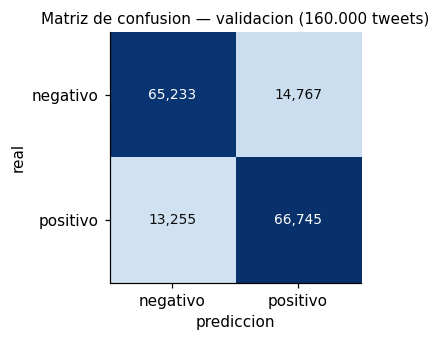

In [3]:
cm_val = confusion_matrix(y_true, y_pred)
graficar_confusion(cm_val, CLASES_BIN, "Matriz de confusion — validacion (160.000 tweets)",
                   "05_confusion_validacion.png")

### Chequeo de overfitting: el mismo modelo en train y validacion

Para diagnosticar sobreajuste no alcanza con mirar validacion: hay que comparar la
performance del **mismo modelo** sobre los datos con los que se entreno y sobre los
que no vio. Las metricas fueron calculadas y persistidas por la notebook 04
(`data/processed/metricas_train_val.csv`).

In [4]:
metricas_tv = pd.read_csv(DATA_PROCESSED / "metricas_train_val.csv")
brecha = metricas_tv.loc[0, "accuracy"] - metricas_tv.loc[1, "accuracy"]
print(f"Brecha de accuracy train - validacion: {brecha:.4f} ({brecha*100:.1f} puntos)")
metricas_tv.round(4)

Brecha de accuracy train - validacion: 0.0217 (2.2 puntos)


,conjunto,accuracy,precision,recall,f1
0,train (1.440.000),0.8466,0.8399,0.8564,0.8481
1,validacion (160.000),0.8249,0.8188,0.8343,0.8265


**Lectura**: la brecha es chica (~2,3 puntos de accuracy; F1 0,8495 en train vs
0,8266 en validacion). El modelo **no esta sobreajustando**: generaliza casi igual
sobre datos no vistos. Dos razones estructurales:

1. La regularizacion L2 que trae `LogisticRegression` por defecto penaliza
   coeficientes grandes.
2. Hay 1.440.000 ejemplos para ~350.000 parametros: memorizar es mas "caro" para el
   optimizador que aprender el patron general.

Ademas, que el accuracy sobre el propio train sea ~0,85 (lejos de 1,0) confirma el
**techo por ruido de etiquetas**: hay tweets identicos con etiquetas opuestas que
ningun modelo puede acertar, ni siquiera memorizando.

**Precision y recall por clase**: negativo tuvo precision 0,8309 y recall 0,8163;
positivo tuvo precision 0,8195 y recall 0,8338. Son numeros parecidos entre las dos
clases (diferencia menor a 2 puntos), lo que muestra que el modelo no favorece a
una clase por sobre la otra.

**Matriz de confusion**: de 160.000 tweets de validacion, 132.011 fueron acertados y
27.989 errados. De los errores, 14.697 eran negativos que el modelo predijo como
positivos, y 13.292 eran positivos que predijo como negativos — numeros parecidos
entre si, sin un sesgo fuerte hacia un lado.

### Ejemplos de errores

Falsos positivos = tweets negativos que el modelo predijo positivos (y viceversa).
Se muestran los errores donde el modelo estaba **mas confiado**, que son los mas
informativos para el analisis de la notebook 06.

In [5]:
val_txt = val.join(train.loc[val["idx"], ["text"]].reset_index(drop=True))

fp = val_txt[(val_txt["y_true"] == 0) & (val_txt["proba_pos"] >= 0.5)].nlargest(5, "proba_pos")
fn = val_txt[(val_txt["y_true"] == 1) & (val_txt["proba_pos"] < 0.5)].nsmallest(5, "proba_pos")

print("=== Falsos positivos (reales negativos, prediccion positiva) ===")
for _, r in fp.iterrows():
    print(f"  p(pos)={r['proba_pos']:.3f} | {r['text']}")
print()
print("=== Falsos negativos (reales positivos, prediccion negativa) ===")
for _, r in fn.iterrows():
    print(f"  p(pos)={r['proba_pos']:.3f} | {r['text']}")

=== Falsos positivos (reales negativos, prediccion positiva) ===
  p(pos)=0.997 | @MsKitty0303  your welcome
  p(pos)=0.994 | @JonasAustralia That quote is amazing. I almost have up on love  Thank you.
  p(pos)=0.993 | @thisisjulze goood luccck love *L( 
  p(pos)=0.993 | Great. History. Yay... 
  p(pos)=0.993 | @Denise183rd thanks 

=== Falsos negativos (reales positivos, prediccion negativa) ===
  p(pos)=0.000 | @ainz0417 I'm sorry you are feeling sad and sick. I hope you feel better soon. 
  p(pos)=0.001 | my mom was here today  it's not allowed 2 leave the hospital but my dad picked her up  But now she's back there &amp; I'm lonely &amp; sad again
  p(pos)=0.001 | ... sorry GPGMail 
  p(pos)=0.001 | @seonaid_bbz Awww gutted 
  p(pos)=0.001 | @my2gs Oh, no!  Tragic! 


## 2. Test manual (dominio distinto)

Aca se usa el **modelo final entrenado con los 1.600.000 tweets**. El test manual
tiene 498 tweets etiquetados a mano sobre queries tematicas (productos, marcas,
personas), un dominio distinto del training. La evaluacion binaria usa los 359
tweets no neutrales.

In [6]:
vec = joblib.load(VECTORIZER_JOBLIB)
lr = joblib.load(MODELO_JOBLIB)

test = pd.read_parquet(TEST_CLEAN_PARQUET)
assert len(test) == 498

proba_test = lr.predict_proba(vec.transform(test["text_clean"]))[:, 1]
test["proba_pos"] = proba_test

test_bin = test[test[TARGET] != 2].copy()
yb_true = (test_bin[TARGET] == 4).astype(int)
yb_pred = (test_bin["proba_pos"] >= 0.5).astype(int)

print(f"Tweets binarios del test manual: {len(test_bin)}\n")
print(f"accuracy : {accuracy_score(yb_true, yb_pred):.4f}")
print(f"precision: {precision_score(yb_true, yb_pred):.4f}")
print(f"recall   : {recall_score(yb_true, yb_pred):.4f}")
print(f"F1-score : {f1_score(yb_true, yb_pred):.4f}\n")
print(classification_report(yb_true, yb_pred, target_names=CLASES_BIN, digits=4))

Tweets binarios del test manual: 359

accuracy : 0.8273
precision: 0.7970
recall   : 0.8846
F1-score : 0.8385

              precision    recall  f1-score   support

    negativo     0.8662    0.7684    0.8144       177
    positivo     0.7970    0.8846    0.8385       182

    accuracy                         0.8273       359
   macro avg     0.8316    0.8265    0.8265       359
weighted avg     0.8312    0.8273    0.8266       359



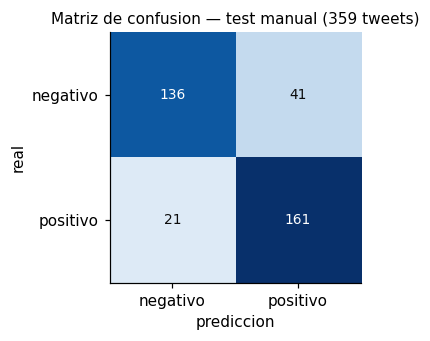

In [7]:
cm_test = confusion_matrix(yb_true, yb_pred)
graficar_confusion(cm_test, CLASES_BIN, "Matriz de confusion — test manual (359 tweets)",
                   "05_confusion_test_manual.png")

## 3. Extension: clase neutral por umbral de incertidumbre

El training no tiene clase neutral, asi que el modelo **no puede aprenderla**. Como
aproximacion exploratoria se define una zona de incertidumbre alrededor de 0.5:

```
si  0.5 - delta <= P(positivo) <= 0.5 + delta  ->  neutral
```

Se evalua contra las 3 clases reales del test manual para distintos `delta`.
**Esto no es el modelo principal**: es una ilustracion de que se puede (y que no)
recuperar sin datos neutrales de entrenamiento.

In [8]:
CLASES_3 = ["negativo", "neutral", "positivo"]
y3_true = test[TARGET].map({0: 0, 2: 1, 4: 2}).to_numpy()

resultados = []
for delta in (0.05, 0.10, 0.15, 0.20, 0.25):
    y3_pred = np.where(
        test["proba_pos"] < 0.5 - delta, 0,
        np.where(test["proba_pos"] > 0.5 + delta, 2, 1),
    )
    resultados.append({
        "delta": delta,
        "accuracy_3clases": accuracy_score(y3_true, y3_pred),
        "recall_neutral": recall_score(y3_true, y3_pred, labels=[1], average=None)[0],
        "pct_predicho_neutral": (y3_pred == 1).mean(),
    })
pd.DataFrame(resultados).round(3)

,delta,accuracy_3clases,recall_neutral,pct_predicho_neutral
0,0.05,0.582,0.058,0.070
1,0.10,0.562,0.115,0.141
2,0.15,0.552,0.187,0.213
3,0.20,0.560,0.288,0.271
4,0.25,0.548,0.403,0.363


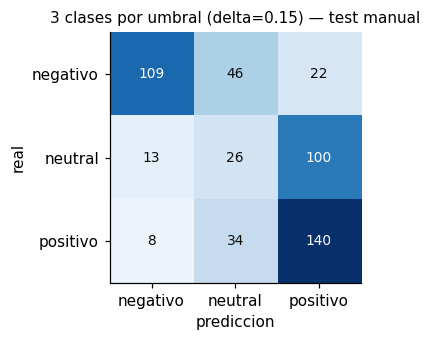

              precision    recall  f1-score   support

    negativo      0.838     0.616     0.710       177
     neutral      0.245     0.187     0.212       139
    positivo      0.534     0.769     0.631       182

    accuracy                          0.552       498
   macro avg      0.539     0.524     0.518       498
weighted avg      0.562     0.552     0.542       498



In [9]:
delta = 0.15
y3_pred = np.where(
    test["proba_pos"] < 0.5 - delta, 0,
    np.where(test["proba_pos"] > 0.5 + delta, 2, 1),
)
cm3 = confusion_matrix(y3_true, y3_pred)
graficar_confusion(cm3, CLASES_3, f"3 clases por umbral (delta={delta}) — test manual",
                   "05_confusion_3clases.png")
print(classification_report(y3_true, y3_pred, target_names=CLASES_3, digits=3))

## Resumen de la evaluacion

- **Validacion (160.000 tweets):** el modelo alcanza las metricas esperables para
  TF-IDF + Logistic Regression en Sentiment140 (~0,80), con errores simetricos
  entre clases.
- **Train vs validacion:** la brecha de ~2,3 puntos de accuracy descarta
  sobreajuste; el techo de ~0,85 sobre el propio train refleja el ruido de
  etiquetado del dataset.
- **Test manual (359 tweets):** el desempenio se sostiene fuera del dominio de
  entrenamiento, senial de que el modelo aprendio vocabulario de sentimiento
  general y no un artefacto del etiquetado por emoticones.
- **Neutral por umbral:** la zona de incertidumbre recupera solo una parte de los
  neutrales reales; sin ejemplos neutrales en el training, la aproximacion tiene un
  techo bajo. Queda documentada como extension, no como resultado principal.
- Los errores mas confiados del modelo (arriba) anticipan el analisis de sarcasmo
  e ironia de la notebook 06.